# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4152s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

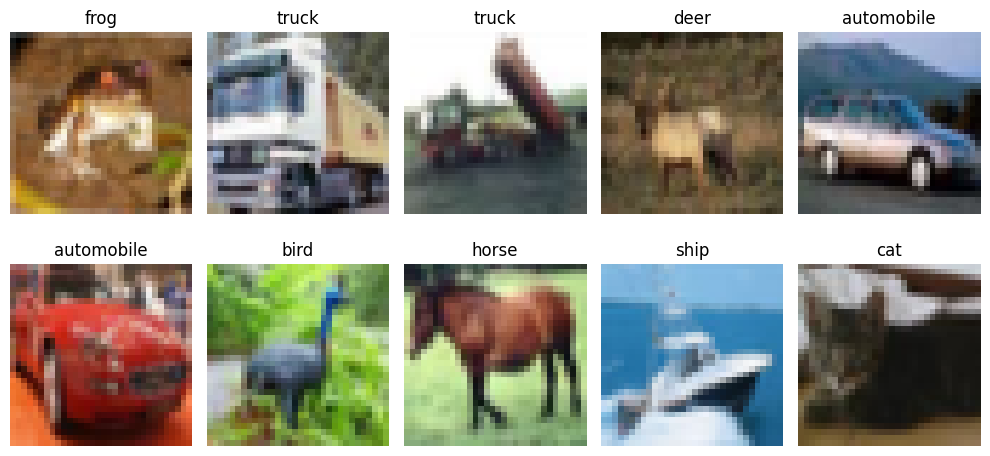

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2687 - loss: 1.9889 - val_accuracy: 0.2978 - val_loss: 1.8938
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3286 - loss: 1.8481 - val_accuracy: 0.3678 - val_loss: 1.7797
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3499 - loss: 1.7917 - val_accuracy: 0.3688 - val_loss: 1.7709
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3608 - loss: 1.7538 - val_accuracy: 0.4074 - val_loss: 1.6796
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3697 - loss: 1.7309 - val_accuracy: 0.4166 - val_loss: 1.6556
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3819 - loss: 1.7002 - val_accuracy: 0.4076 - val_loss: 1.6413
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3902 - loss: 1.6813 - val_accuracy: 0.4256 - val_loss: 1.6156
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3934 - loss: 1.6693 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4341 - loss: 1.5870
ANN Test Accuracy: 0.4341000020503998


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[cnn_early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4743 - loss: 1.4724 - val_accuracy: 0.5570 - val_loss: 1.2299
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6070 - loss: 1.1275 - val_accuracy: 0.6042 - val_loss: 1.1169
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6695 - loss: 0.9525 - val_accuracy: 0.6360 - val_loss: 1.0701
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7050 - loss: 0.8401 - val_accuracy: 0.6990 - val_loss: 0.8863
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7391 - loss: 0.7485 - val_accuracy: 0.6704 - val_loss: 0.9835
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7674 - loss: 0.6615 - val_accuracy: 0.7110 - val_loss: 0.8739
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7943 - loss: 0.5888 - val_accuracy: 0.6556 - val_loss: 1.0513
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8097 - loss: 0.5355 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7019 - loss: 0.8840
CNN Test Accuracy: 0.7019000053405762


## 📈 Compare Learning Curves

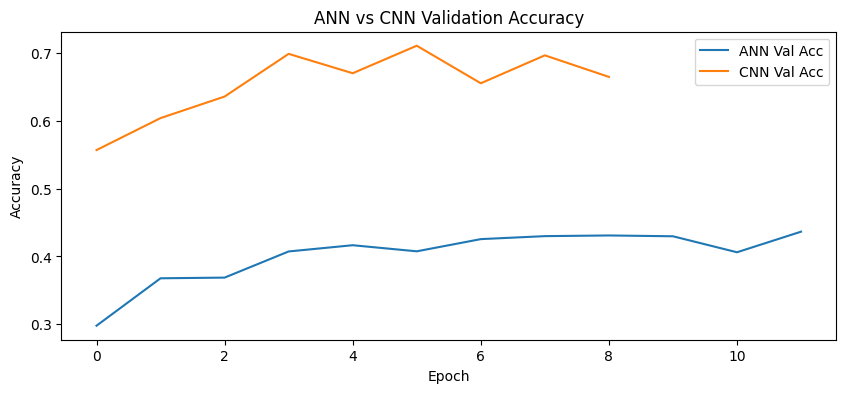

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4063 - loss: 1.6445 - val_accuracy: 0.4540 - val_loss: 1.5314
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5067 - loss: 1.3864 - val_accuracy: 0.4366 - val_loss: 2.0384
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5517 - loss: 1.2760 - val_accuracy: 0.6054 - val_loss: 1.1499
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5804 - loss: 1.1917 - val_accuracy: 0.5878 - val_loss: 1.1720
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6055 - loss: 1.1357 - val_accuracy: 0.6494 - val_loss: 1.0060
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6203 - loss: 1.0908 - val_accuracy: 0.6368 - val_loss: 1.0467
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6356 - loss: 1.0496 - val_accuracy: 0.6352 - val_loss: 1.0470
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6499 - loss: 1.0144 - val_acc

# 📊 Final Comparison Table

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7073 - loss: 0.8577
Augmented CNN Test Accuracy: 0.7073000073432922


In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})

comparison

,Model,Test Accuracy
0,ANN,0.4341
1,CNN,0.7019
2,Augmented CNN,0.7073


## Student Learning Tasks Completed

The following beginner-level experiments were implemented:

- Increased the number of ANN dense layers and observed model performance.
- Modified the CNN architecture using 32 → 64 → 128 convolutional filters.
- Increased the maximum training epochs to 20.
- Implemented EarlyStopping to prevent unnecessary training and reduce overfitting.
- Applied data augmentation and trained an Augmented CNN model.

### Performance Observation

The ANN achieved a test accuracy of **43.41%**, while the CNN achieved **70.19%**.  
The Augmented CNN achieved the highest test accuracy of **70.73%**.

The results demonstrate that CNN-based models perform significantly better than ANN for image classification because they preserve and learn spatial image features. Data augmentation further improved model generalization.

## Conclusion

- The ANN achieved **43.41% test accuracy** but showed limited performance because flattening the images removes spatial relationships between pixels.
- The CNN achieved **70.19% test accuracy**, demonstrating that convolutional layers effectively learn spatial features such as edges, textures, and object patterns.
- The Augmented CNN achieved the highest test accuracy of **70.73%**, showing a slight improvement in model generalization.
- Techniques such as **Dropout, Batch Normalization, EarlyStopping, and Data Augmentation** helped control overfitting and improve training effectiveness.
- Overall, the experiment demonstrates why CNN architectures are more suitable than traditional ANN models for image classification tasks such as CIFAR-10.